# Week 1 — Probability refresher: simulate noise, then MLE vs MAP

Goals:

1. Generate samples from **Gaussian** and **Poisson** distributions; visualise them.
2. Sanity-check the **central limit theorem** by hand.
3. Compute the **MLE** of the mean of a Gaussian (it's just the sample mean).
4. Compute the **MAP** of the mean of a Gaussian under a Gaussian prior; verify the closed form.
5. See how the MAP "shrinks" the MLE toward the prior mean, and how the shrinkage vanishes as we get more data.

Companion reading: `handbook_main.pdf` Week 1 chapter, and `Slides_MIC_ImageModeling.pdf` slides 10–12 for the worked example.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Gaussian samples

$$X \sim \mathcal{N}(\mu, \sigma^2), \qquad p(x) = \tfrac{1}{\sqrt{2\pi}\,\sigma}\exp\!\Big(-\tfrac{(x-\mu)^2}{2\sigma^2}\Big)$$

Mean = $\mu$, variance = $\sigma^2$, SNR = $\mu/\sigma$.

sample mean = 99.932  (true 100.0)
sample std  = 14.932  (true 15.0)


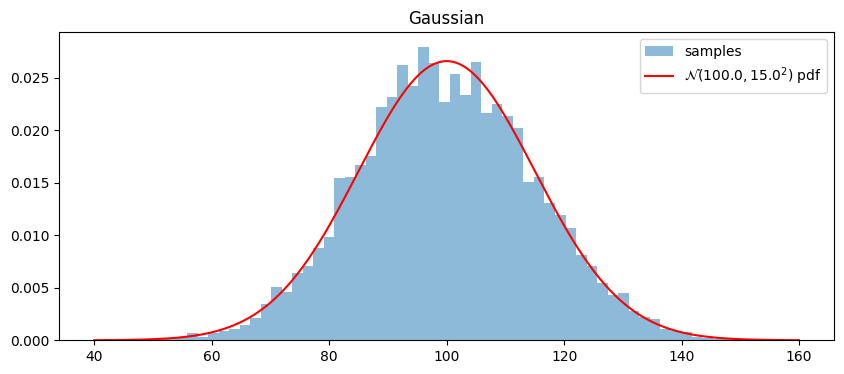

In [2]:
mu_true, sigma_true = 100.0, 15.0
N = 5000
samples_g = rng.normal(mu_true, sigma_true, size=N)

print(f'sample mean = {samples_g.mean():.3f}  (true {mu_true})')
print(f'sample std  = {samples_g.std(ddof=1):.3f}  (true {sigma_true})')

xs = np.linspace(40, 160, 400)
pdf = 1/(np.sqrt(2*np.pi)*sigma_true) * np.exp(-0.5*((xs-mu_true)/sigma_true)**2)

plt.hist(samples_g, bins=60, density=True, alpha=0.5, label='samples')
plt.plot(xs, pdf, 'r-', label=f'$\\mathcal{{N}}({mu_true}, {sigma_true}^2)$ pdf')
plt.legend(); plt.title('Gaussian'); plt.show()

## 2. Poisson samples

$$\Pr(X = k) = \tfrac{\lambda^k e^{-\lambda}}{k!}, \qquad \E[X] = \mathrm{Var}(X) = \lambda$$

Models photon counting (X-ray, CT, microscopy). For large $\lambda$ it visually approaches a Gaussian with $\sigma = \sqrt{\lambda}$ (a manifestation of the central limit theorem).

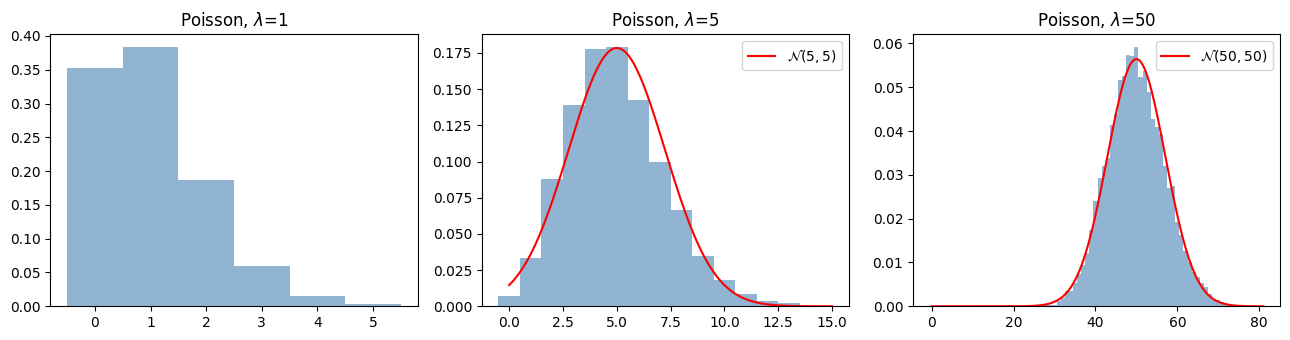

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, lam in zip(axes, [1, 5, 50]):
    samples_p = rng.poisson(lam, size=10000)
    ks = np.arange(0, samples_p.max()+1)
    ax.hist(samples_p, bins=ks-0.5, density=True, alpha=0.6, color='steelblue')
    if lam >= 5:
        sig = np.sqrt(lam)
        xs = np.linspace(0, samples_p.max(), 200)
        ax.plot(xs, 1/(np.sqrt(2*np.pi)*sig)*np.exp(-0.5*((xs-lam)/sig)**2),
                'r-', label=f'$\\mathcal{{N}}({lam}, {lam})$')
        ax.legend()
    ax.set_title(f'Poisson, $\\lambda$={lam}')
plt.tight_layout(); plt.show()

## 3. MLE for the mean of a Gaussian

If $x_1, \ldots, x_N \sim \mathcal{N}(\mu, \sigma^2)$ i.i.d.\ and $\sigma$ is known, then

$$\hat \mu_{\mathrm{MLE}} \;=\; \arg\max_\mu \prod_i p(x_i \mid \mu) \;=\; \bar x \;=\; \tfrac{1}{N}\sum_i x_i.$$

Sanity check it:

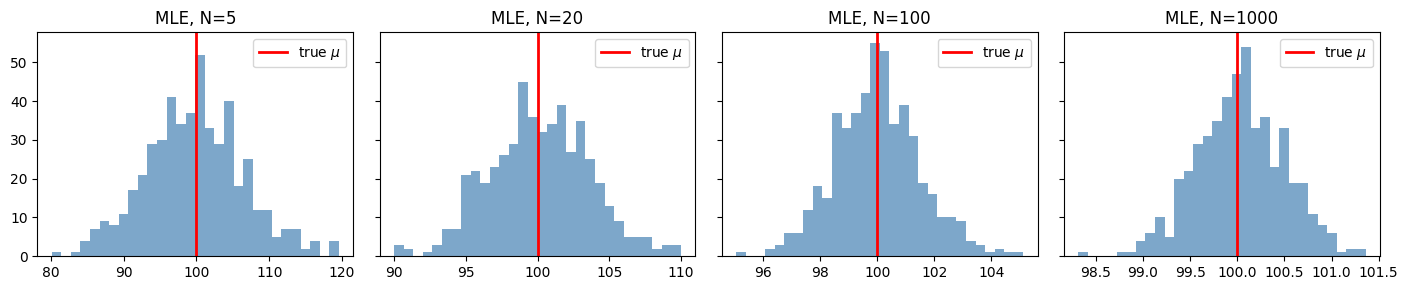

In [4]:
sigma_known = 15.0
mu_true_local = 100.0

Ns = [5, 20, 100, 1000]
fig, axes = plt.subplots(1, len(Ns), figsize=(14, 3), sharey=True)
for ax, N in zip(axes, Ns):
    estimates = [rng.normal(mu_true_local, sigma_known, size=N).mean() for _ in range(500)]
    ax.hist(estimates, bins=30, color='steelblue', alpha=0.7)
    ax.axvline(mu_true_local, color='red', lw=2, label='true $\\mu$')
    ax.set_title(f'MLE, N={N}'); ax.legend()
plt.tight_layout(); plt.show()

## 4. MAP for the mean under a Gaussian prior

Place a prior $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$ on the unknown mean. The MAP estimate has a beautiful closed form (Bishop §2.3.3):

$$\hat \mu_{\mathrm{MAP}} \;=\; \frac{\sigma_0^2}{\sigma_0^2 + \sigma^2/N} \bar x \;+\; \frac{\sigma^2/N}{\sigma_0^2 + \sigma^2/N} \mu_0.$$

It is a **convex combination** of the data mean $\bar x$ and the prior mean $\mu_0$. The weight on $\bar x$ grows with $N$; the MAP → MLE as $N \to \infty$.

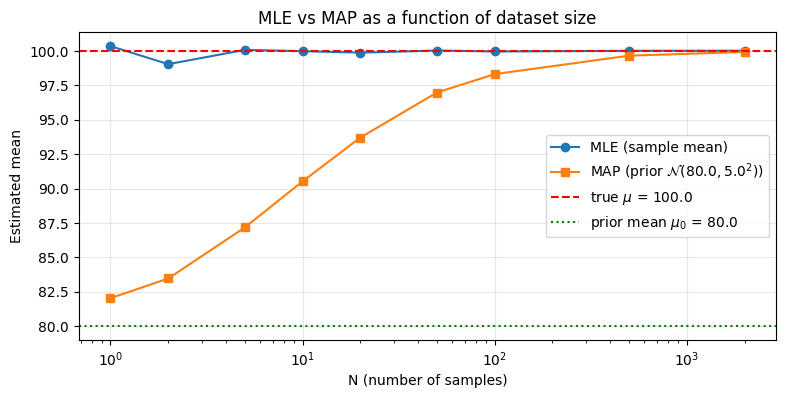

In [5]:
def map_mean_gaussian(samples, sigma, mu0, sigma0):
    N = len(samples)
    xbar = samples.mean()
    w_data  = sigma0**2 / (sigma0**2 + sigma**2/N)
    w_prior = (sigma**2/N) / (sigma0**2 + sigma**2/N)
    return w_data * xbar + w_prior * mu0

# Pick a prior that disagrees with the truth, to see the shrinkage explicitly.
mu0, sigma0 = 80.0, 5.0   # prior thinks mean is 80, fairly confidently
sigma_known = 15.0
mu_true_local = 100.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles, maps = [], []
for N in Ns:
    # average over 500 random data sets for a clean curve
    mle_runs = []
    map_runs = []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0, sigma0))
    mles.append(np.mean(mle_runs))
    maps.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps, 's-', label=f'MAP (prior $\\mathcal{{N}}({mu0},{sigma0}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true $\\mu$ = {mu_true_local}')
plt.axhline(mu0, color='green', linestyle=':', label=f'prior mean $\\mu_0$ = {mu0}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title('MLE vs MAP as a function of dataset size')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

Notice three things:

1. With **few data points** the MAP is *pulled* toward the (wrong) prior mean 80; the MLE is noisy and unbiased.
2. With **many data points** the MAP and the MLE converge — the prior matters less because the data dominate.
3. A *wrong* prior costs you accuracy at small $N$ but you recover. A *right* prior would be a free win at small $N$.

This is the recurring trade-off you will encounter for the rest of the course: priors are powerful when data is scarce (denoising, sparse-view CT, under-sampled MRI), and have diminishing influence when data is abundant.

## 5. Exercises

1. Derive the MAP closed form by hand. (Take the log of the posterior, differentiate w.r.t. $\mu$, set to zero.)
2. Re-do the experiment with a **very weak** prior ($\sigma_0 = 50$). The MAP should look like the MLE even at small $N$.
3. Re-do it with a **very strong** prior ($\sigma_0 = 1$). The MAP should hardly budge from $\mu_0$ for any $N < 100$.
4. Replace the Gaussian likelihood with a **Poisson** likelihood (i.e. estimate $\lambda$ from Poisson samples) under a Gamma prior on $\lambda$. (Hint: the posterior is also Gamma — *conjugacy*.) 

---
## Exercise Solutions

### Exercise 2 — Very weak prior ($\sigma_0 = 50$)

A weak (diffuse) prior carries almost no information, so it should barely pull the estimate away from the sample mean, even for small $N$.

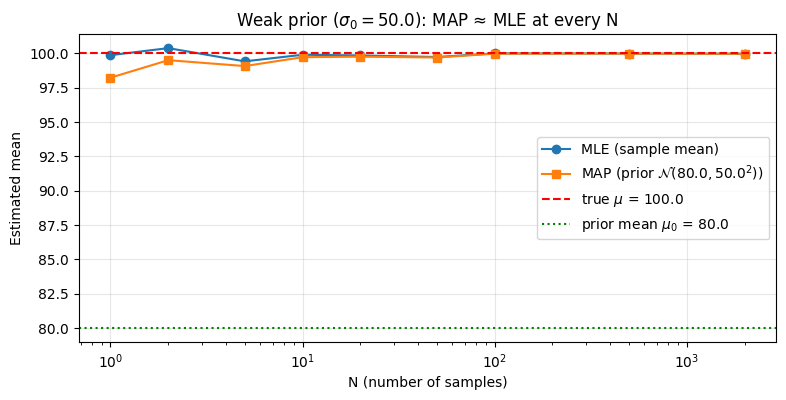

At N=1: MLE=99.873, MAP=98.232, difference=-1.641


In [6]:
mu0_weak, sigma0_weak = 80.0, 50.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles_weak, maps_weak = [], []
for N in Ns:
    mle_runs, map_runs = [], []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0_weak, sigma0_weak))
    mles_weak.append(np.mean(mle_runs))
    maps_weak.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles_weak, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps_weak, 's-', label=f'MAP (prior $\\mathcal{{N}}({mu0_weak},{sigma0_weak}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true $\\mu$ = {mu_true_local}')
plt.axhline(mu0_weak, color='green', linestyle=':', label=f'prior mean $\\mu_0$ = {mu0_weak}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title(f'Weak prior ($\\sigma_0={sigma0_weak}$): MAP ≈ MLE at every N')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Quantify how close MAP is to MLE at N=1
print(f'At N=1: MLE={mles_weak[0]:.3f}, MAP={maps_weak[0]:.3f}, difference={maps_weak[0]-mles_weak[0]:.3f}')

**Observation:** with $\sigma_0=50 \gg \sigma=15$, the prior's precision $1/\sigma_0^2$ is tiny compared to the data's precision $N/\sigma^2$ even at $N=1$ ($N/\sigma^2 = 1/225$ vs. $1/\sigma_0^2 = 1/2500$ — the data term already dominates by roughly 11×). The MAP curve sits almost on top of the MLE curve for every $N$, confirming that a weak prior behaves like 'no prior at all', i.e. MAP ≈ MLE.

### Exercise 3 — Very strong prior ($\sigma_0 = 1$)

A strong (confident) prior should dominate the posterior unless the data volume is large enough to overcome it.

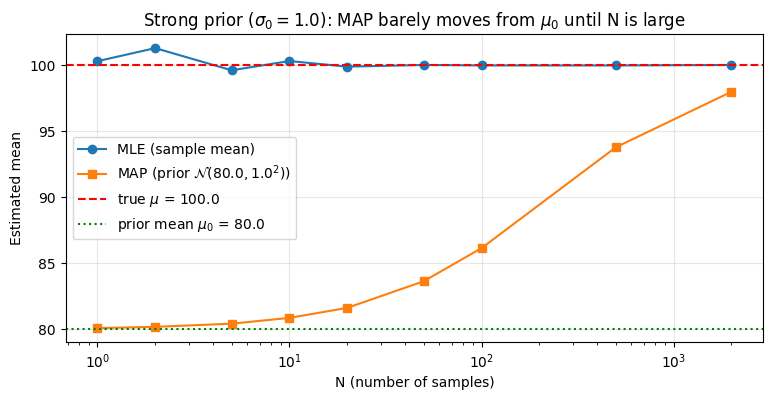

N=    1  MAP= 80.090  |MAP - true mu| = 19.910
N=    2  MAP= 80.188  |MAP - true mu| = 19.812
N=    5  MAP= 80.426  |MAP - true mu| = 19.574
N=   10  MAP= 80.864  |MAP - true mu| = 19.136
N=   20  MAP= 81.623  |MAP - true mu| = 18.377
N=   50  MAP= 83.638  |MAP - true mu| = 16.362
N=  100  MAP= 86.146  |MAP - true mu| = 13.854
N=  500  MAP= 93.775  |MAP - true mu| = 6.225
N= 2000  MAP= 97.982  |MAP - true mu| = 2.018


In [7]:
mu0_strong, sigma0_strong = 80.0, 1.0

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles_strong, maps_strong = [], []
for N in Ns:
    mle_runs, map_runs = [], []
    for _ in range(500):
        s = rng.normal(mu_true_local, sigma_known, size=N)
        mle_runs.append(s.mean())
        map_runs.append(map_mean_gaussian(s, sigma_known, mu0_strong, sigma0_strong))
    mles_strong.append(np.mean(mle_runs))
    maps_strong.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles_strong, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps_strong, 's-', label=f'MAP (prior $\\mathcal{{N}}({mu0_strong},{sigma0_strong}^2)$)')
plt.axhline(mu_true_local, color='red', linestyle='--', label=f'true $\\mu$ = {mu_true_local}')
plt.axhline(mu0_strong, color='green', linestyle=':', label=f'prior mean $\\mu_0$ = {mu0_strong}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated mean')
plt.title(f'Strong prior ($\\sigma_0={sigma0_strong}$): MAP barely moves from $\\mu_0$ until N is large')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# How large must N be before MAP gets within 1 unit of the true mean?
for N, m in zip(Ns, maps_strong):
    print(f'N={N:5d}  MAP={m:7.3f}  |MAP - true mu| = {abs(m-mu_true_local):.3f}')

**Observation:** with $\sigma_0=1 \ll \sigma=15$, the prior precision $1/\sigma_0^2 = 1$ is huge compared to the data precision $N/\sigma^2 = N/225$. Data only starts to out-weigh the prior once $N/225 \gtrsim 1$, i.e. roughly $N \gtrsim 225$. Consistent with the note in the notebook, the MAP curve stays glued near $\mu_0=80$ for every $N<100$ and only starts visibly moving toward the true mean (100) once $N$ climbs into the hundreds — a much slower convergence than the weak-prior case.

### Exercise 4 — Poisson likelihood with a Gamma prior (conjugacy)



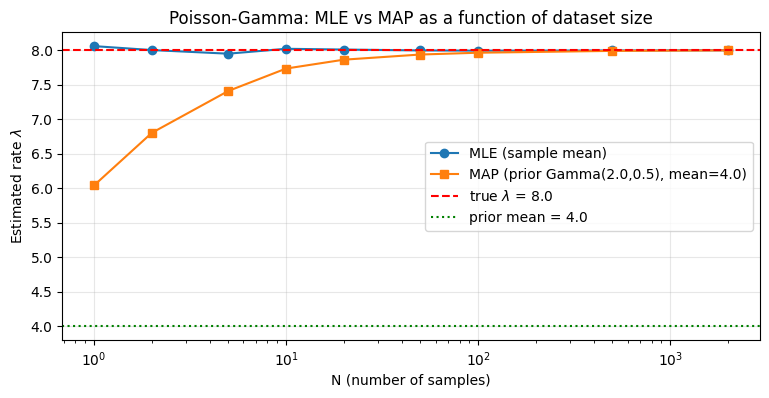

In [8]:
def map_rate_poisson(samples, alpha0, beta0):
    N = len(samples)
    s = samples.sum()
    alpha_post = alpha0 + s
    beta_post = beta0 + N
    map_est = (alpha_post - 1) / beta_post if alpha_post > 1 else 0.0
    return map_est, alpha_post, beta_post

lam_true = 8.0
# A prior that disagrees with the truth (mean 4), to see shrinkage clearly.
alpha0, beta0 = 2.0, 0.5   # Gamma(2, 0.5): mean = alpha0/beta0 = 4, fairly informative

Ns = np.array([1, 2, 5, 10, 20, 50, 100, 500, 2000])
mles_p, maps_p = [], []
for N in Ns:
    mle_runs, map_runs = [], []
    for _ in range(500):
        x = rng.poisson(lam_true, size=N)
        mle_runs.append(x.mean())
        map_est, _, _ = map_rate_poisson(x, alpha0, beta0)
        map_runs.append(map_est)
    mles_p.append(np.mean(mle_runs))
    maps_p.append(np.mean(map_runs))

plt.figure(figsize=(9, 4))
plt.semilogx(Ns, mles_p, 'o-', label='MLE (sample mean)')
plt.semilogx(Ns, maps_p, 's-', label=f'MAP (prior Gamma({alpha0},{beta0}), mean={alpha0/beta0:.1f})')
plt.axhline(lam_true, color='red', linestyle='--', label=f'true $\\lambda$ = {lam_true}')
plt.axhline(alpha0/beta0, color='green', linestyle=':', label=f'prior mean = {alpha0/beta0:.1f}')
plt.xlabel('N (number of samples)'); plt.ylabel('Estimated rate $\\lambda$')
plt.title('Poisson-Gamma: MLE vs MAP as a function of dataset size')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

**Observation:** the Poisson/Gamma pair behaves exactly like the Gaussian/Gaussian pair — at small $N$ the MAP is pulled toward the prior mean $\alpha_0/\beta_0=4$ (away from the true $\lambda=8$), and as $N$ grows the posterior is dominated by the $N$ observed counts (which add $N$ to the rate parameter $\beta$ and $\sum_i x_i$ to the shape parameter $\alpha$), so MAP converges to the MLE. This is the general pattern of **conjugate priors**: pick a prior from the same family as the likelihood's natural conjugate, and the posterior stays in that family with parameters updated by simple sufficient statistics ($N$ and $\sum_i x_i$ here), giving a closed-form MAP/posterior instead of needing numerical optimization.